In [48]:
from Bio.PDB import PDBList, PDBParser, MMCIFParser
import numpy as np
import matplotlib.pyplot as plt

In [11]:
pdbl = PDBList(server = "https://files.rcsb.org")
pdbl.retrieve_pdb_file(pdb_code = "1gzx", pdir = "./Data/", file_format = "mmCif")

Structure exists: './Data/1gzx.cif' 


'./Data/1gzx.cif'

In [14]:
parser = MMCIFParser()

structure = parser.get_structure("hemoglobin", "./Data/1gzx.cif")
model = structure[0]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4384.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4429.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4474.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4519.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4564.
  warni

In [26]:
all_residues = [r.get_resname() for r in model.get_residues()]
print(np.unique(all_residues)) # HOH = water, "OXY", "HEM"

['ALA' 'ARG' 'ASN' 'ASP' 'CYS' 'GLN' 'GLU' 'GLY' 'HEM' 'HIS' 'HOH' 'LEU'
 'LYS' 'MET' 'OXY' 'PHE' 'PRO' 'SER' 'THR' 'TRP' 'TYR' 'VAL']


In [23]:
chainA_residues = [r.get_resname() for r in model["A"].get_residues()]
print(np.unique(chainA_residues))

['ALA' 'ARG' 'ASN' 'ASP' 'CYS' 'GLN' 'GLU' 'GLY' 'HEM' 'HIS' 'HOH' 'LEU'
 'LYS' 'MET' 'OXY' 'PHE' 'PRO' 'SER' 'THR' 'TRP' 'TYR' 'VAL']


In [28]:
residues = list(model.get_residues())

all_ids = []
for i, r in enumerate(residues):
    all_ids.append(r.get_id()[0])
print(np.unique(all_ids))

[' ' 'H_HEM' 'H_OXY' 'W']


- ' ': amino-acid
- 'H_HEM': hem group
- 'H_OXY': ...
- 'W': water molecule

In [24]:
### Reconstruct the SEQUENCE,excluding the ions and water molecules that are present in the PDB coordinates

from Bio.PDB.Polypeptide import PPBuilder

ppb = PPBuilder()
for pp in ppb.build_peptides(structure):
    print(pp.get_sequence())

VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
VHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH
VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
VHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH


In [31]:
chain_a = ppb.build_peptides(structure)[0].get_sequence()
chain_b = ppb.build_peptides(structure)[1].get_sequence()

print(chain_a)
print(chain_b)

VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
VHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH


Exercise:

Extract the carbon alpha coordinates of the protein without the N-terminal histidine tag (first 6
residues) nor the water and ion atoms (hetero atoms).

In [45]:
structure_chain_a = ppb.build_peptides(structure)[0]
print(structure_chain_a)
structure_chain_b = ppb.build_peptides(structure)[1]
print(structure_chain_b)


length = len(structure_chain_a.get_sequence())
print(length)

ac_coords_all = [structure_chain_a[i]["CA"].get_coord() for i in range(length)]


# Exclude first 6 residues
ac_coords = ac_coords_all[6:]

for idx, coords in enumerate(ac_coords):
    print(idx, coords)

<Polypeptide start=1 end=141>
<Polypeptide start=144 end=289>
141
0 [-3.279 20.326  4.298]
1 [-3.633 19.097  7.845]
2 [-7.287 18.021  7.314]
3 [-6.486 16.125  4.158]
4 [-3.521 14.226  5.639]
5 [-5.668 13.335  8.623]
6 [-8.733 12.072  6.63 ]
7 [-6.575 10.347  3.978]
8 [-4.79   9.026  7.079]
9 [-7.808  6.904  8.231]
10 [-8.74  5.62  4.76]
11 [-5.421  3.907  5.011]
12 [-5.674  0.352  3.699]
13 [-9.119  0.912  2.166]
14 [-8.085  3.557 -0.364]
15 [-8.391  1.027 -3.26 ]
16 [-11.699  -0.367  -2.005]
17 [-12.922   3.295  -1.605]
18 [-11.602   4.289  -5.142]
19 [-13.457   1.161  -6.623]
20 [-16.694   2.165  -4.768]
21 [-16.322   5.848  -5.933]
22 [-16.041   4.709  -9.505]
23 [-19.173   2.517  -9.102]
24 [-21.18    5.452  -7.604]
25 [-20.002   7.547 -10.547]
26 [-21.046   5.084 -13.336]
27 [-24.512   4.674 -11.639]
28 [-25.396   8.317 -10.624]
29 [-24.023   9.821 -13.989]
30 [-24.005   7.155 -16.763]
31 [-22.38    9.487 -19.198]
32 [-19.012   8.922 -17.541]
33 [-19.319   5.272 -18.91 ]
34 [-18.4

Exercise:

Create a all-to-all contact map for the protein residues using the
coordinates array we generated previously. Use 6 Å and 12 Å as
the inner and outer cutoffs, respectively.

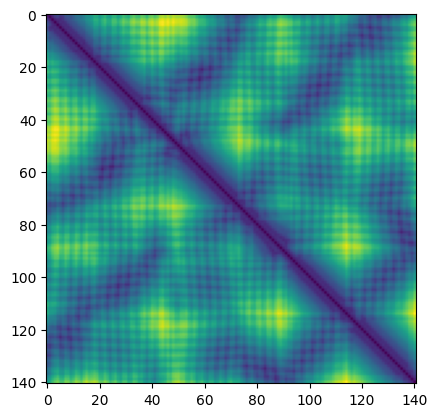

In [52]:
alphacarbons = [structure_chain_a[i]["CA"] for i in range(length)]

distance = alphacarbons[0] - alphacarbons[1]

distance_matrix = np.empty((length, length))
for i in range(length):
    for j in range(i, length):
        dij = alphacarbons[i] - alphacarbons[j]
        distance_matrix[i, j] = dij
        distance_matrix[j, i] = dij

plt.imshow(distance_matrix)

### Superimposing

- Each "model" is a different experimental measurement 
- if we have multiple models within one structure, we need to compare them
- first, we need to superimpose (affine transformation: traslation + rotation + scaling)
- then, we can make a meaningful comparison

- we compute the mean squared deviation and see which parts of the structure are more mobile and which are more fixed. Sometimes is free movement, other times it is that some instantiation of protein is binding to a molecule (heteroatom) and some other is not.
 

-------------------
# Exercise
--------------------

Let us analyze and describe the structure of human
hemoglobin:

1. Download the mmCIF file from PDB and parse it
2. Extract the sequence of the protein subunits and
obtain the amino acid percentages
3. Identify, for each chain, the residue that is closest to
a Fe atom. Remember to account for all the atoms in each residue, not only the C alpha. Check your result with the PDB structure visualizer.
4. Calculate the radius of gyration of the individual
chains, as well as for the complete structure
5. (Optional) Compare the structure with that of
hemoglobin when bound to oxygens (PDB: 1GZX)
